In [2]:
import h5py as h5
import re
import numpy as np
import matplotlib.pyplot as plt



filename = "k_05_nr_27000/ncharge.h5"


def load_modes_NF(filename, prefix="mode_"):
    """
    Devuelve:
      ells:  (nmode,) int
      N:     (nmode, nt) float64
      F:     (nmode, nt) float64
    Asume datasets: f"{prefix}{ell:05d}_N" y f"{prefix}{ell:05d}_F"
    """
    pat = re.compile(rf"^{re.escape(prefix)}(\d{{5}})_(N|F)$")

    with h5.File(filename, "r") as f:
        # identifica qué modos existen
        found = {}
        for k in f.keys():
            m = pat.match(k)
            if m:
                ell = int(m.group(1))
                kind = m.group(2)  # "N" o "F"
                found.setdefault(ell, set()).add(kind)

        ells = np.array(sorted(found.keys()), dtype=int)

        # filtra solo los que tienen ambos N y F
        ells = np.array([ell for ell in ells if found[ell] == {"N", "F"}], dtype=int)
        if ells.size == 0:
            raise ValueError("No encontré pares completos (N,F) con el patrón esperado.")

        # longitud temporal (nt) desde el primer modo
        first = ells[0]
        nt = f[f"{prefix}{first:05d}_N"].shape[0]

        N = np.empty((ells.size, nt), dtype=np.float64)
        F = np.empty((ells.size, nt), dtype=np.float64)

        for i, ell in enumerate(ells):
            N[i, :] = f[f"{prefix}{ell:05d}_N"][:]
            F[i, :] = f[f"{prefix}{ell:05d}_F"][:]

    return ells, N, F

with h5.File(filename, 'r') as f:
    time = f["mode_00000_t"][:]   

filename = "k_05_nr_27000/ncharge.h5"
ells, NC, Flux = load_modes_NF(filename)

print(ells.shape, NC.shape, Flux.shape)  




(81,) (81, 35998) (81, 35998)


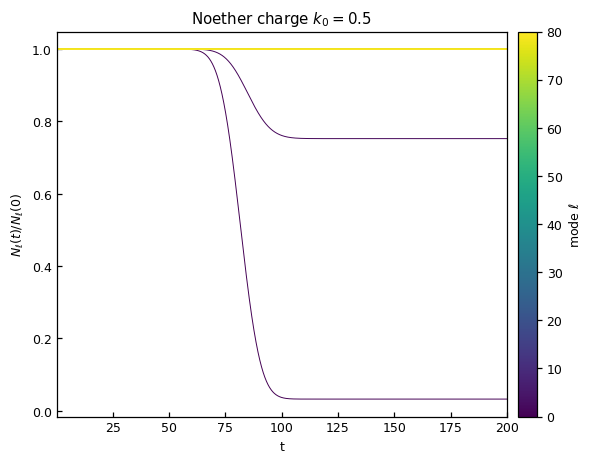

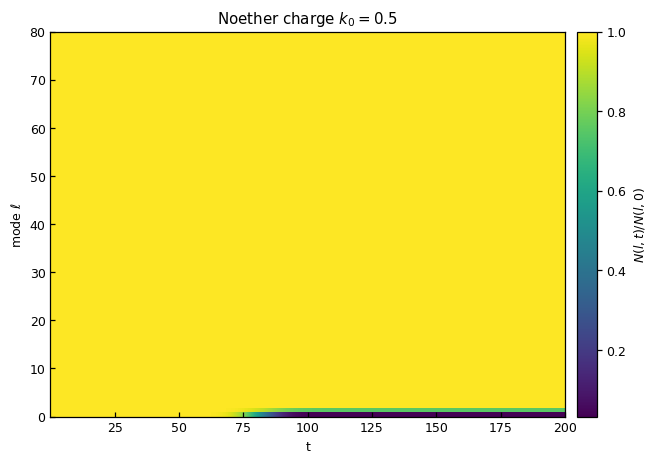

In [3]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import os
import re

# --- Extraer k0 del nombre del archivo:  k_05  ->  k0 = 0.5
base = os.path.basename(os.path.dirname(filename))  # "k_05"
m = re.search(r"k_(\d+)", base)
if m is None:
    raise ValueError("No pude extraer k0 del nombre del directorio.")

k0 = float(m.group(1)) / 10.0


ells, N, F = load_modes_NF(filename, prefix="mode_")


# Si "time" viene del archivo, úsalo. Si no, asegúrate de tenerlo definido.
# time = ...

# --- 1) Ordenar por ell (recomendado para que el eje y sea monotónico y el gradiente sea limpio)
order = np.argsort(ells)
ells_s = np.asarray(ells)[order]
N_s    = np.asarray(N)[order, :]

# --- 2) (Opcional pero sano) Asegurar que time esté ordenado; si no, reordenar también las columnas
t = np.asarray(time)
if np.any(np.diff(t) < 0):
    torder = np.argsort(t)
    t = t[torder]
    N_s = N_s[:, torder]

# =========================
# Gráfica de líneas con gradiente por ℓ
# =========================
fig, ax = plt.subplots(figsize=(7, 5))

norm = mpl.colors.Normalize(vmin=ells_s.min(), vmax=ells_s.max())
cmap = plt.get_cmap("viridis")  # puedes cambiar a "plasma", "magma", etc.

for ell, series in zip(ells_s, N_s):
    ax.plot(t, series/N_s[ell,0], linewidth=0.7, color=cmap(norm(ell)))

ax.set_xlabel("t")
ax.set_ylabel(r"$N_\ell(t)/N_\ell(0)$")
ax.set_title(rf"Noether charge $k_0 = {k0}$ ")

# Barra de color que mapea color -> ell
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r"mode $\ell$")

# Mejoras típicas de ejes (opcional)
ax.margins(x=0)
ax.tick_params(axis="both", which="both", direction="in")
plt.show()

# =========================
# Heatmap ℓ–t con ejes físicos (t y ℓ)
# =========================
fig, ax = plt.subplots(figsize=(8, 5))

# extent = [xmin, xmax, ymin, ymax] mapea la matriz a coordenadas reales
extent = [t.min(), t.max(), ells_s.min(), ells_s.max()]

im = ax.imshow(
    N_s/N_s[:, 0][:, np.newaxis],
    aspect="auto",
    origin="lower",
    extent=extent,
    interpolation="nearest",  # evita suavizado engañoso; cambia si quieres
)

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label(r"$N(l,t)/N(l,0)$")

ax.set_xlabel("t")
ax.set_ylabel(r"mode $\ell$")
ax.set_title(rf"Noether charge $k_0 = {k0}$")
ax.tick_params(axis="both", which="both", direction="in")
plt.show()



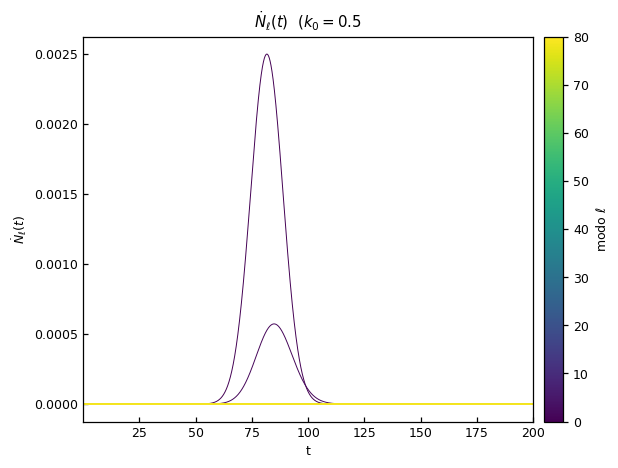

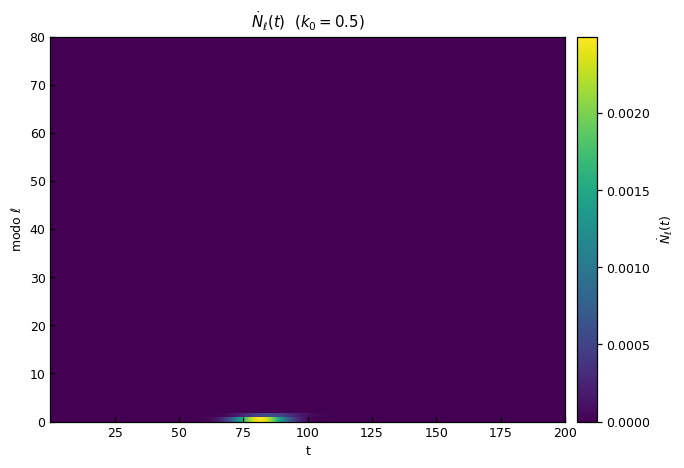

In [4]:
# --- Ordenar por ell
order  = np.argsort(ells)
ells_s = np.asarray(ells)[order]
F_s    = np.asarray(F)[order, :]

# --- Alinear time
t = np.asarray(time)
if np.any(np.diff(t) < 0):
    torder = np.argsort(t)
    t = t[torder]
    F_s = F_s[:, torder]

# =========================
# Gráfica de líneas con gradiente por ℓ
# =========================
fig, ax = plt.subplots(figsize=(7,5))

norm = mpl.colors.Normalize(vmin=ells_s.min(), vmax=ells_s.max())
cmap = plt.get_cmap("viridis")

for ell, series in zip(ells_s, F_s):
    ax.plot(t, series, linewidth=0.7, color=cmap(norm(ell)))

ax.set_xlabel("t")
ax.set_ylabel(r"$\dot N_\ell(t)$")
ax.set_title(rf"$\dot N_\ell(t)$  ($k_0={k0}$")

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r"modo $\ell$")

ax.margins(x=0)
ax.tick_params(axis="both", which="both", direction="in")
plt.show()

fig, ax = plt.subplots(figsize=(8,5))

extent = [t.min(), t.max(), ells_s.min(), ells_s.max()]
im = ax.imshow(
    F_s,
    aspect="auto",
    origin="lower",
    extent=extent,
    interpolation="nearest"
)

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label(r"$\dot N_\ell(t)$")

ax.set_xlabel("t")
ax.set_ylabel(r"modo $\ell$")
ax.set_title(rf"$\dot N_\ell(t)$  ($k_0={k0}$)")
ax.tick_params(axis="both", which="both", direction="in")
plt.show()



t.shape = (35995,)
N shapes: (81, 35995) (81, 35995) (81, 35995) (81, 35995)
t range: 0.022223456858714373 200.0 dt~ 0.005555864214678595


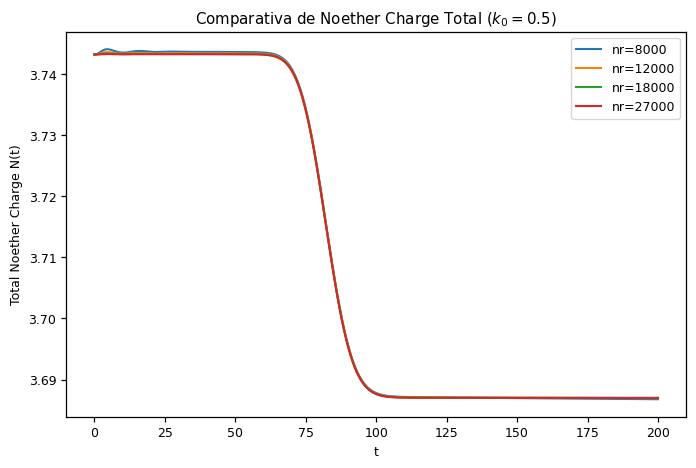

p123 (por modo): (81,)
p234 (por modo): (81,)
p123 median = 1.9049475515691126
p234 median = 1.9331763080826792


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


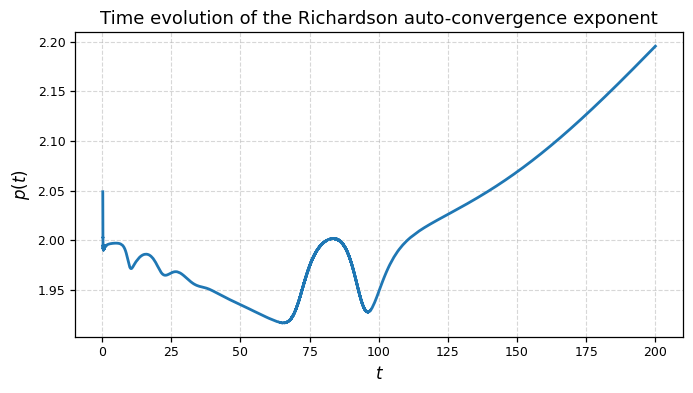

In [5]:
import numpy as np
import h5py as h5

file_1 = "k_05_nr_8000/ncharge.h5"
file_2 = "k_05_nr_12000/ncharge.h5"
file_3 = "k_05_nr_18000/ncharge.h5"
file_4 = "k_05_nr_27000/ncharge.h5"

# --- Cargar tiempos ---
with h5.File(file_1, "r") as f: time_1 = f["mode_00000_t"][:]
with h5.File(file_2, "r") as f: time_2 = f["mode_00000_t"][:]
with h5.File(file_3, "r") as f: time_3 = f["mode_00000_t"][:]
with h5.File(file_4, "r") as f: time_4 = f["mode_00000_t"][:]

# --- Cargar N(t) por modo ---
ells, N_1, F_1 = load_modes_NF(file_1)
ells, N_2, F_2 = load_modes_NF(file_2)
ells, N_3, F_3 = load_modes_NF(file_3)
ells, N_4, F_4 = load_modes_NF(file_4)

# --- 1) Elegir malla temporal común con el mayor número de puntos ---
# Tomamos como referencia la más fina (menor dt), y recortamos al solapamiento.
times = [time_1, time_2, time_3, time_4]
dts   = [t[1] - t[0] for t in times]
iref  = int(np.argmin(dts))               # índice del time más fino
tref0 = times[iref][0]
tref  = times[iref]

tmin = max(time_1[0], time_2[0], time_3[0], time_4[0])
tmax = min(time_1[-1], time_2[-1], time_3[-1], time_4[-1])

mask = (tref >= tmin) & (tref <= tmax)
t = tref[mask]                            # malla común (máxima cantidad de puntos)

# --- 2) Interpolar cada N_i al mismo vector de tiempos t ---
def interp_modes(time_src, Nsrc, t_tgt):
    # Nsrc: (nmode, Nt_src)  ->  (nmode, Nt_tgt)
    return np.vstack([np.interp(t_tgt, time_src, Nsrc[m]) for m in range(Nsrc.shape[0])])

N1c = interp_modes(time_1, N_1, t)
N2c = interp_modes(time_2, N_2, t)
N3c = interp_modes(time_3, N_3, t)
N4c = interp_modes(time_4, N_4, t)

print("t.shape =", t.shape)
print("N shapes:", N1c.shape, N2c.shape, N3c.shape, N4c.shape)
print("t range:", t[0], t[-1], "dt~", t[1]-t[0])

N1_total = N1c.sum(axis=0)
N2_total = N2c.sum(axis=0)
N3_total = N3c.sum(axis=0)
N4_total = N4c.sum(axis=0)

# --- 3) Gráfica comparativa ---
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(t, N1_total, label="nr=8000")
ax.plot(t, N2_total, label="nr=12000")
ax.plot(t, N3_total, label="nr=18000")   
ax.plot(t, N4_total, label="nr=27000")
ax.set_xlabel("t")
ax.set_ylabel("Total Noether Charge N(t)")
ax.set_title(rf"Comparativa de Noether Charge Total ($k_0={k0}$)")
ax.legend()
plt.show()

# --  4) Autoconvergencia de Richardson --- 

r = 1.5  # factor de refinamiento por nivel

def richardson_p(Uc, Um, Uf, axis=1, eps=1e-300):
    """
    Calcula p por modo usando ||Uc-Um|| / ||Um-Uf|| = r^p
    Uc, Um, Uf: arrays (nmode, Nt)
    axis=1: norma a lo largo del tiempo
    """
    d1 = Uc - Um
    d2 = Um - Uf
    n1 = np.linalg.norm(d1, axis=axis)
    n2 = np.linalg.norm(d2, axis=axis)

    # evitar divisiones por cero
    ratio = (n1 + eps) / (n2 + eps)
    p = np.log(ratio) / np.log(r)
    return p, ratio, n1, n2

# p usando triples (1,2,3) y (2,3,4)
p123, R123, n12, n23 = richardson_p(N1c, N2c, N3c)
p234, R234, n23b, n34 = richardson_p(N2c, N3c, N4c)

print("p123 (por modo):", p123.shape)
print("p234 (por modo):", p234.shape)

# si quieres un solo p global (promedio robusto, ignorando inf/nan)
p123_med = np.nanmedian(p123[np.isfinite(p123)])
p234_med = np.nanmedian(p234[np.isfinite(p234)])
print("p123 median =", p123_med)
print("p234 median =", p234_med)


import numpy as np
import matplotlib.pyplot as plt

r = 1.5
eps = 1e-300  # evita log(0)

# Diferencias y normas L2 sobre modos en cada tiempo
d12_t = np.linalg.norm(N2c - N3c, axis=0)   # (Nt,)
d23_t = np.linalg.norm(N3c - N4c, axis=0)   # (Nt,)

p_t = np.log((d12_t + eps) / (d23_t + eps)) / np.log(r)

plt.figure(figsize=(7,4))

plt.plot(t[40:], p_t[40:], linewidth=2)

plt.xlabel(r"$t$", fontsize=12)
plt.ylabel(r"$p(t)$", fontsize=12)

plt.title(r"Time evolution of the Richardson auto-convergence exponent", fontsize=13)

plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("auto_convergence.eps", format="eps")
plt.show()



In [6]:
import os
import numpy as np

def Nacc_vs_k0_ell(base_name,
                   base_dir="/home/flavio/Codes/KG-Y/sweep_k/",
                   N=200, KMIN=0.0, KMAX=20.0,
                   sort="asc"):
    """
    Versión simple:
      - k0 = linspace(KMIN, KMAX, N)
      - carpeta = f"{base_name}{i:03d}"
      - archivo = <carpeta>/ncharge.h5

    Retorna:
      k_out: k0 sólo de las corridas que sí tienen ncharge.h5 (alineado con columnas)
      ells_values
      N_acc_matrix
    """
    base_dir = os.path.abspath(base_dir)
    k_values = np.linspace(KMIN, KMAX, N, endpoint=True)

    idx = np.arange(N)
    if sort.lower() == "desc":
        idx = idx[::-1]

    N_acc_list = []
    kept_k = []
    ells_values = None

    for i in idx:
        run_dir = os.path.join(base_dir, f"{base_name}{i:03d}")
        file_path = os.path.join(run_dir, "ncharge.h5")
        #print(f"Procesando {file_path}...")

        if not os.path.exists(file_path):
            continue  # corrida incompleta / no generó output

        ells, Nmode, F = load_modes_NF(file_path)

        if ells_values is None:
            ells_values = np.array(ells, copy=True)
        else:
            if len(ells_values) != len(ells) or np.any(ells_values != np.array(ells)):
                raise ValueError(f"Los ell no coinciden entre archivos. Revisa {file_path}")
            
        N0 = Nmode[:, 0]
        Nf = Nmode[:, -1]

        N_acc = 1.0 - Nf / N0

        N_acc_list.append(N_acc)
        kept_k.append(k_values[i])


    k_out = np.array(kept_k, dtype=float)
    N_acc_matrix = np.column_stack(N_acc_list)

    return k_out, ells_values, N_acc_matrix


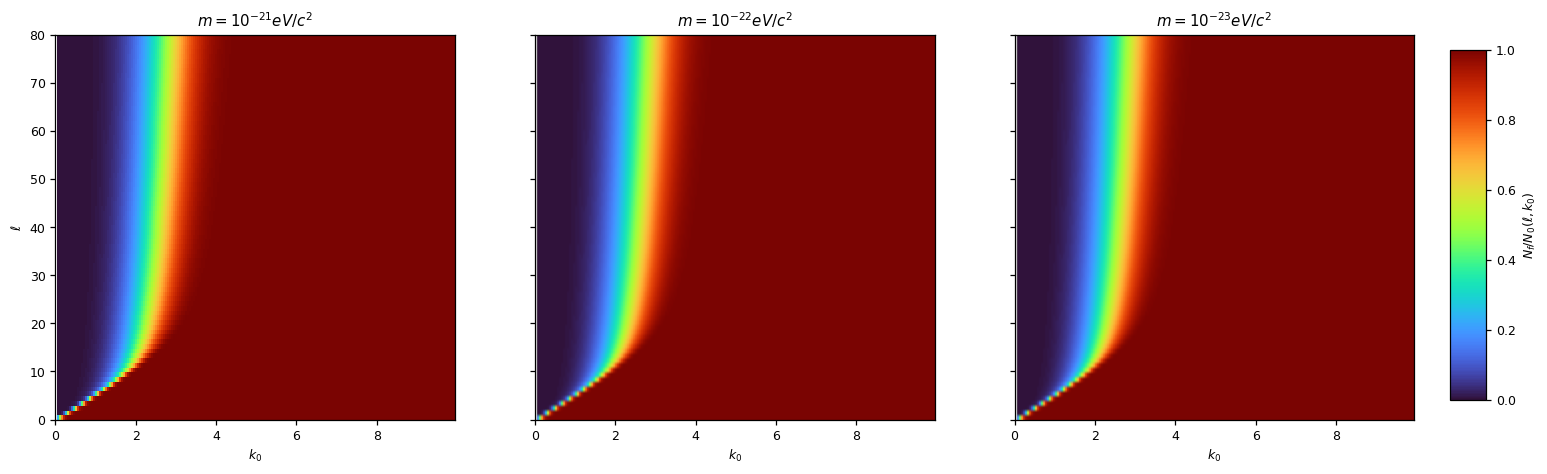

In [7]:
k00, ell00, N_acc00 = Nacc_vs_k0_ell("k_0m_")
k22, ell22, N_acc22 = Nacc_vs_k0_ell("k_m22_")
k19, ell19, N_acc19 = Nacc_vs_k0_ell("k_m19_")
k21, ell21, N_acc21 = Nacc_vs_k0_ell("k_m21_")
k20, ell20, N_acc20 = Nacc_vs_k0_ell("k_m20_")
k23, ell23, N_acc23 = Nacc_vs_k0_ell("k_m23_")
k220, ell220, N_acc220 = Nacc_vs_k0_ell("k_2m20_")
k320, ell320, N_acc320 = Nacc_vs_k0_ell("k_3m20_")
k420, ell420, N_acc420 = Nacc_vs_k0_ell("k_4m20_")
k520, ell520, N_acc520 = Nacc_vs_k0_ell("k_5m20_")
k620, ell620, N_acc620 = Nacc_vs_k0_ell("k_6m20_")
k720, ell720, N_acc720 = Nacc_vs_k0_ell("k_7m20_")
k820, ell820, N_acc820 = Nacc_vs_k0_ell("k_8m20_")
k920, ell920, N_acc920 = Nacc_vs_k0_ell("k_9m20_")


# Rango común
kmin = max(k22.min(), k21.min(), k23.min(), k19.min(), k220.min(), k320.min(), k420.min(), k520.min(), k620.min(), k720.min(), k820.min(), k920.min())
kmax = min(k22.max(), k21.max(), k23.max(), k19.max(), k220.max(), k320.max(), k420.max(), k520.max(), k620.max(), k720.max(), k820.max(), k920.max())
ellmin = max(ell22.min(), ell21.min(), ell23.min(), ell19.min(), ell220.min(), ell320.min(), ell420.min(), ell520.min(), ell620.min(), ell720.min(), ell820.min(), ell920.min())
ellmax = min(ell22.max(), ell21.max(), ell23.max(), ell19.max(), ell220.max(), ell320.max(), ell420.max(), ell520.max(), ell620.max(), ell720.max(), ell820.max(), ell920.max())

extent = [kmin, kmax, ellmin, ellmax]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Caso k_
im0 = axes[1].imshow((N_acc22), aspect='auto', origin='lower',
                     extent=extent, cmap='turbo')
axes[1].set_title(r'$m = 10^{-22} eV/c^2$')
axes[1].set_xlabel(r'$k_0$')

# Caso k_m21
im1 = axes[0].imshow((N_acc21), aspect='auto', origin='lower',
                     extent=extent, cmap='turbo')
axes[0].set_title(r'$m = 10^{-21} eV/c^2$')
axes[0].set_xlabel(r'$k_0$')
axes[0].set_ylabel(r'$\ell$')

# Caso k_m23
im2 = axes[2].imshow((N_acc23), aspect='auto', origin='lower',
                     extent=extent, cmap='turbo')
axes[2].set_title(r'$m = 10^{-23} eV/c^2$')
axes[2].set_xlabel(r'$k_0$')    

# Dejar espacio a la derecha para la colorbar
plt.subplots_adjust(right=0.88)

# Eje exclusivo para la colorbar
cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im1, cax=cax)
cbar.set_label(r'$N_{f} / N_{0}(\ell, k_0)$')

plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


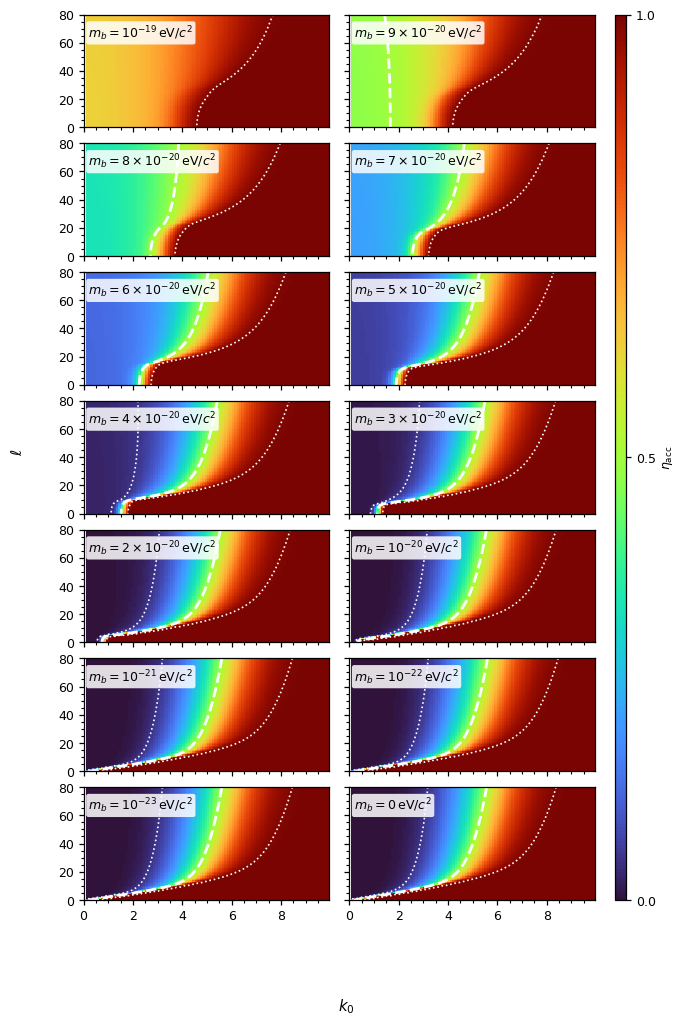

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ---------- estilo tipo paper ----------
plt.rcParams.update({
    "font.size": 9,
    "axes.linewidth": 0.9,
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "xtick.minor.size": 2.0,
    "ytick.minor.size": 2.0,
    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,
    "savefig.dpi": 350,
})

tau_main = 0.5
tau_hi   = 0.95
tau_lo   = 0.01

def overlay_contours_survival(ax, k, ell, S, taus, **kwargs):
    K, L = np.meshgrid(k, ell)
    levels = [1.0 - t for t in taus]
    ax.contour(K, L, S, levels=levels, **kwargs)

# ====== RECORTE EN k0 ======
KMAX_PLOT = 10.0

# --- rango común (limitado) ---
kmin = max(k22.min(), k21.min(), k23.min(), k19.min(), k20.min(), k220.min(), k320.min(), k420.min(), k520.min(), k620.min(), k720.min(), k820.min(), k920.min(), k00.min())
kmax_common = min(k22.max(), k21.max(), k23.max(), k19.max(), k20.max(), k220.max(), k320.max(), k420.max(), k520.max(), k620.max(), k720.max(), k820.max(), k920.max(), k00.max())
kmax = min(kmax_common, KMAX_PLOT)

ellmin = max(ell22.min(), ell21.min(), ell23.min(), ell19.min(), ell20.min(), ell220.min(), ell320.min(), ell420.min(), ell520.min(), ell620.min(), ell720.min(), ell820.min(), ell920.min(), ell00.min())
ellmax = min(ell22.max(), ell21.max(), ell23.max(), ell19.max(), ell20.max(), ell220.max(), ell320.max(), ell420.max(), ell520.max(), ell620.max(), ell720.max(), ell820.max(), ell920.max(), ell00.max())

# -------- paneles con metadata para ordenar por m_b --------
# Orden por tamaño de m_b (mayor -> menor). Para 2e-20 y 4e-20 metemos el valor real.
panels = [
    {"mb": 1e-19, "Nacc": N_acc19,  "k": k19,  "ell": ell19,  "txt": r"$m_b=10^{-19}\,\mathrm{eV}/c^2$"},
    {"mb": 4e-20, "Nacc": N_acc420, "k": k420, "ell": ell420, "txt": r"$m_b=4\times10^{-20}\,\mathrm{eV}/c^2$"},
    {"mb": 3e-20, "Nacc": N_acc320, "k": k320, "ell": ell320, "txt": r"$m_b=3\times10^{-20}\,\mathrm{eV}/c^2$"},
    {"mb": 2e-20, "Nacc": N_acc220, "k": k220, "ell": ell220, "txt": r"$m_b=2\times10^{-20}\,\mathrm{eV}/c^2$"},
    {"mb": 1e-20, "Nacc": N_acc20,  "k": k20,  "ell": ell20,  "txt": r"$m_b=10^{-20}\,\mathrm{eV}/c^2$"},
    {"mb": 9e-20, "Nacc": N_acc920, "k": k920, "ell": ell920, "txt": r"$m_b=9\times10^{-20}\,\mathrm{eV}/c^2$"},
    {"mb": 8e-20, "Nacc": N_acc820, "k": k820, "ell": ell820, "txt": r"$m_b=8\times10^{-20}\,\mathrm{eV}/c^2$"},
    {"mb": 7e-20, "Nacc": N_acc720, "k": k720, "ell": ell720, "txt": r"$m_b=7\times10^{-20}\,\mathrm{eV}/c^2$"},
    {"mb": 6e-20, "Nacc": N_acc620, "k": k620, "ell": ell620, "txt": r"$m_b=6\times10^{-20}\,\mathrm{eV}/c^2$"},
    {"mb": 5e-20, "Nacc": N_acc520, "k": k520, "ell": ell520, "txt": r"$m_b=5\times10^{-20}\,\mathrm{eV}/c^2$"},
    {"mb": 1e-21, "Nacc": N_acc21,  "k": k21,  "ell": ell21,  "txt": r"$m_b=10^{-21}\,\mathrm{eV}/c^2$"},
    {"mb": 1e-22, "Nacc": N_acc22,  "k": k22,  "ell": ell22,  "txt": r"$m_b=10^{-22}\,\mathrm{eV}/c^2$"},
    {"mb": 1e-23, "Nacc": N_acc23,  "k": k23,  "ell": ell23,  "txt": r"$m_b=10^{-23}\,\mathrm{eV}/c^2$"},
    {"mb": 0.0, "Nacc": N_acc00,  "k": k00,  "ell": ell00,  "txt": r"$m_b=0\,\mathrm{eV}/c^2$"},
]
panels = sorted(panels, key=lambda d: d["mb"], reverse=True)

# ====== FIGURA 2 COLUMNAS + COLORBAR ======
n = len(panels)
nrows, ncols = 7, 2  # 14 slots para todos los paneles

fig = plt.figure(figsize=(7.0, 11.5))  # más altura para 7 filas
gs = fig.add_gridspec(nrows, ncols + 1, width_ratios=[1, 1, 0.045],
                      wspace=0.12, hspace=0.14)

axes = []
for r in range(nrows):
    for c in range(ncols):
        axes.append(fig.add_subplot(gs[r, c]))
cax = fig.add_subplot(gs[:, -1])  # colorbar a la derecha

im = None
for idx, p in enumerate(panels):
    ax = axes[idx]
    k   = np.asarray(p["k"])
    ell = np.asarray(p["ell"])
    Nacc = np.asarray(p["Nacc"])

    # recorte en k
    keep_k = (k >= kmin) & (k <= kmax)
    k_plot = k[keep_k]

    # recorte en ell (por consistencia visual)
    keep_ell = (ell >= ellmin) & (ell <= ellmax)
    ell_plot = ell[keep_ell]

    Nacc_plot = Nacc[np.ix_(keep_ell, keep_k)]

    im = ax.imshow(
        Nacc_plot,
        origin="lower",
        aspect="auto",
        extent=[k_plot.min(), k_plot.max(), ell_plot.min(), ell_plot.max()],
        cmap="turbo", vmin=0, vmax=1,
        interpolation="nearest",
        rasterized=True,  # útil si guardas en PDF
    )

    # etiqueta dentro del panel (mejor que title)
    ax.text(
        0.02, 0.92, p["txt"],
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.85),
    )

    overlay_contours_survival(ax, k_plot, ell_plot, Nacc_plot, [tau_main],
                              colors="w", linewidths=2.0, linestyles="--")
    overlay_contours_survival(ax, k_plot, ell_plot, Nacc_plot, [tau_hi, tau_lo],
                              colors="w", linewidths=1.2, linestyles=":")

    ax.set_xlim(kmin, kmax)
    ax.set_ylim(ellmin, ellmax)
    ax.minorticks_on()
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))

    # ticks x solo en la última fila
    r = idx // ncols
    if r != nrows - 1:
        ax.tick_params(labelbottom=False)

    # ticks y solo en la primera columna
    c = idx % ncols
    if c != 0:
        ax.tick_params(labelleft=False)

# apaga ejes sobrantes (slots vacíos)
for j in range(n, nrows * ncols):
    axes[j].axis("off")

# labels globales
fig.supxlabel(r"$k_0$")
fig.supylabel(r"$\ell$")

# colorbar único
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r"$\eta_{\rm acc}$")
cbar.set_ticks([0.0, 0.5, 1.0])

# salida "paper"
fig.savefig("NfN0_lk0.eps", format="eps", bbox_inches="tight")
fig.savefig("NfN0_lk0.png", bbox_inches="tight", dpi=450)
plt.show()



The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


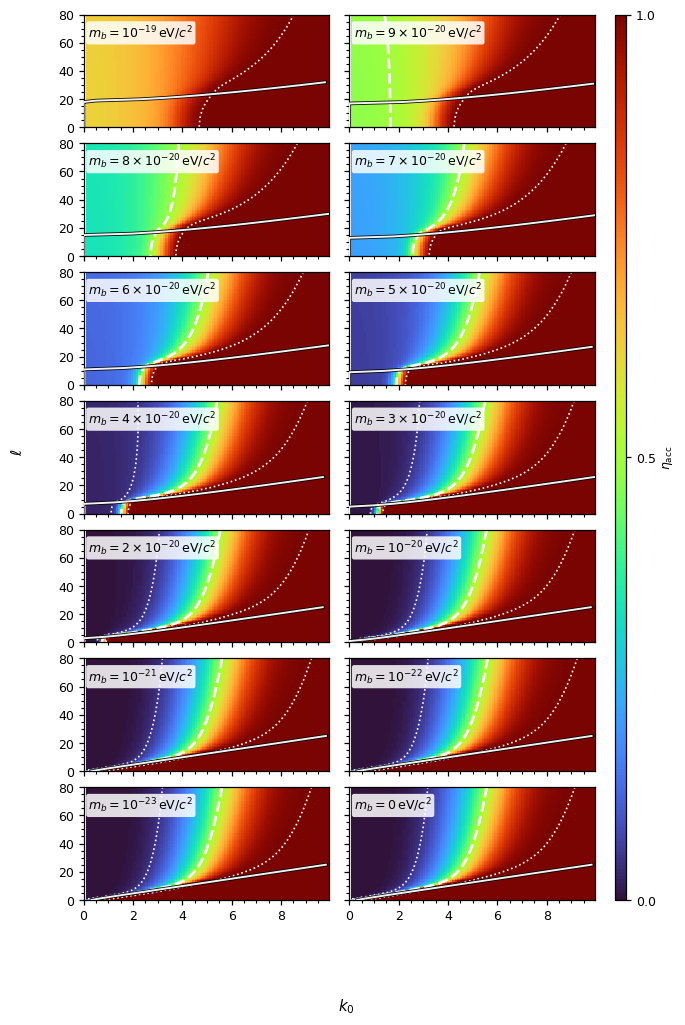

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ---------- estilo tipo paper ----------
plt.rcParams.update({
    "font.size": 9,
    "axes.linewidth": 0.9,
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "xtick.minor.size": 2.0,
    "ytick.minor.size": 2.0,
    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,
    "savefig.dpi": 350,
})

tau_main = 0.5
tau_hi   = 0.95
tau_lo   = 0.001

def overlay_contours_survival(ax, k, ell, S, taus, **kwargs):
    K, L = np.meshgrid(k, ell)
    levels = [1.0 - t for t in taus]
    ax.contour(K, L, S, levels=levels, **kwargs)

# ====== RECORTE EN k0 ======
KMAX_PLOT = 10.0

# --- rango común (limitado) ---
kmin = max(k22.min(), k21.min(), k23.min(),
           k19.min(), k20.min(),
           k220.min(), k320.min(), k420.min(), k520.min(),
           k620.min(), k720.min(), k820.min(), k920.min(),
           k00.min())

kmax_common = min(k22.max(), k21.max(), k23.max(),
                  k19.max(), k20.max(),
                  k220.max(), k320.max(), k420.max(), k520.max(),
                  k620.max(), k720.max(), k820.max(), k920.max(),
                  k00.max())

kmax = min(kmax_common, KMAX_PLOT)

ellmin = max(ell22.min(), ell21.min(), ell23.min(),
             ell19.min(), ell20.min(),
             ell220.min(), ell320.min(), ell420.min(), ell520.min(),
             ell620.min(), ell720.min(), ell820.min(), ell920.min(),
             ell00.min())

ellmax = min(ell22.max(), ell21.max(), ell23.max(),
             ell19.max(), ell20.max(),
             ell220.max(), ell320.max(), ell420.max(), ell520.max(),
             ell620.max(), ell720.max(), ell820.max(), ell920.max(),
             ell00.max())

# -------- paneles con metadata para ordenar por m_b --------
panels = [
    {"mb": 1e-19, "Nacc": N_acc19,  "k": k19,  "ell": ell19,  "txt": r"$m_b=10^{-19}\,\mathrm{eV}/c^2$"},
    {"mb": 9e-20, "Nacc": N_acc920, "k": k920, "ell": ell920, "txt": r"$m_b=9\times10^{-20}\,\mathrm{eV}/c^2$"},
    {"mb": 8e-20, "Nacc": N_acc820, "k": k820, "ell": ell820, "txt": r"$m_b=8\times10^{-20}\,\mathrm{eV}/c^2$"},
    {"mb": 7e-20, "Nacc": N_acc720, "k": k720, "ell": ell720, "txt": r"$m_b=7\times10^{-20}\,\mathrm{eV}/c^2$"},
    {"mb": 6e-20, "Nacc": N_acc620, "k": k620, "ell": ell620, "txt": r"$m_b=6\times10^{-20}\,\mathrm{eV}/c^2$"},
    {"mb": 5e-20, "Nacc": N_acc520, "k": k520, "ell": ell520, "txt": r"$m_b=5\times10^{-20}\,\mathrm{eV}/c^2$"},
    {"mb": 4e-20, "Nacc": N_acc420, "k": k420, "ell": ell420, "txt": r"$m_b=4\times10^{-20}\,\mathrm{eV}/c^2$"},
    {"mb": 3e-20, "Nacc": N_acc320, "k": k320, "ell": ell320, "txt": r"$m_b=3\times10^{-20}\,\mathrm{eV}/c^2$"},
    {"mb": 2e-20, "Nacc": N_acc220, "k": k220, "ell": ell220, "txt": r"$m_b=2\times10^{-20}\,\mathrm{eV}/c^2$"},
    {"mb": 1e-20, "Nacc": N_acc20,  "k": k20,  "ell": ell20,  "txt": r"$m_b=10^{-20}\,\mathrm{eV}/c^2$"},
    {"mb": 1e-21, "Nacc": N_acc21,  "k": k21,  "ell": ell21,  "txt": r"$m_b=10^{-21}\,\mathrm{eV}/c^2$"},
    {"mb": 1e-22, "Nacc": N_acc22,  "k": k22,  "ell": ell22,  "txt": r"$m_b=10^{-22}\,\mathrm{eV}/c^2$"},
    {"mb": 1e-23, "Nacc": N_acc23,  "k": k23,  "ell": ell23,  "txt": r"$m_b=10^{-23}\,\mathrm{eV}/c^2$"},
    {"mb": 0.0,   "Nacc": N_acc00,  "k": k00,  "ell": ell00,  "txt": r"$m_b=0\,\mathrm{eV}/c^2$"},
]
panels = sorted(panels, key=lambda d: d["mb"], reverse=True)

# ==========================================================
# Overlay: k0_tr(ell) computed from V_eff max for each mu
# ==========================================================
R_s_th = 1.0

# Calibración (tu dato)
mu_ref = 0.00972837  # mu when m_b = 1e-22
mb_ref = 1e-22

def mb_to_mu(mb):
    return 0.0 if mb == 0.0 else mu_ref * (mb / mb_ref)

def V_eff_thr(r, ell, mu):
    L = ell*(ell+1.0)
    return (1.0 - R_s_th/r) * (mu**2 + L/r**2 + R_s_th/r**3)

def k0_tr_numeric_for_mu(ell, mu, rmax_search=1e4, n_coarse=25000):
    """
    k0_tr(ell) = sqrt(max(Vmax - mu^2, 0)), where Vmax is max_{r>Rs} V_eff_thr(r,ell,mu).
    Robust: logspace scan + local parabolic refinement.
    """
    eps = 1e-10
    r = np.logspace(np.log10(R_s_th*(1.0+eps)), np.log10(rmax_search*R_s_th), n_coarse)
    V = V_eff_thr(r, ell, mu)

    i = int(np.argmax(V))

    # local parabolic refinement
    if 0 < i < len(r)-1:
        x1, x2, x3 = r[i-1], r[i], r[i+1]
        y1, y2, y3 = V[i-1], V[i], V[i+1]

        denom = (x1-x2)*(x1-x3)*(x2-x3)
        a = (x3*(y2-y1) + x2*(y1-y3) + x1*(y3-y2)) / denom
        b = (x3**2*(y1-y2) + x2**2*(y3-y1) + x1**2*(y2-y3)) / denom

        if a < 0.0:
            r_peak = -b/(2.0*a)
            r_peak = min(max(r_peak, min(x1,x3)), max(x1,x3))
            V_peak = V_eff_thr(r_peak, ell, mu)
        else:
            V_peak = y2
    else:
        V_peak = V[i]

    return np.sqrt(max(V_peak - mu**2, 0.0))

# cache: mu -> dict {ell_int: k0tr}
k0tr_cache = {}

def get_k0tr_curve(ell_curve, mu_panel):
    """
    ell_curve: array of integer ells to evaluate
    returns: k_curve same shape
    caches per mu and per ell to save time across panels
    """
    key = float(mu_panel)
    if key not in k0tr_cache:
        k0tr_cache[key] = {}

    d = k0tr_cache[key]
    k_curve = np.empty_like(ell_curve, dtype=float)
    for i, e in enumerate(ell_curve):
        e = int(e)
        if e not in d:
            d[e] = k0_tr_numeric_for_mu(e, mu_panel)
        k_curve[i] = d[e]
    return k_curve

# ====== FIGURA 2 COLUMNAS + COLORBAR ======
n = len(panels)
nrows, ncols = 7, 2  # 14 slots para todos los paneles

fig = plt.figure(figsize=(7.0, 11.5))
gs = fig.add_gridspec(nrows, ncols + 1, width_ratios=[1, 1, 0.045],
                      wspace=0.12, hspace=0.14)

axes = []
for r in range(nrows):
    for c in range(ncols):
        axes.append(fig.add_subplot(gs[r, c]))
cax = fig.add_subplot(gs[:, -1])

im = None
for idx, p in enumerate(panels):
    ax = axes[idx]
    k   = np.asarray(p["k"])
    ell = np.asarray(p["ell"])
    Nacc = np.asarray(p["Nacc"])

    # recorte en k
    keep_k = (k >= kmin) & (k <= kmax)
    k_plot = k[keep_k]

    # recorte en ell (consistencia visual)
    keep_ell = (ell >= ellmin) & (ell <= ellmax)
    ell_plot = ell[keep_ell]

    Nacc_plot = Nacc[np.ix_(keep_ell, keep_k)]

    im = ax.imshow(
        Nacc_plot,
        origin="lower",
        aspect="auto",
        extent=[k_plot.min(), k_plot.max(), ell_plot.min(), ell_plot.max()],
        cmap="turbo", vmin=0, vmax=1,
        interpolation="nearest",
        rasterized=True,
    )

    # etiqueta del panel
    ax.text(
        0.02, 0.92, p["txt"],
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.85),
    )

    # contornos de eta_acc (tus thresholds)
    overlay_contours_survival(ax, k_plot, ell_plot, Nacc_plot, [tau_main],
                              colors="w", linewidths=2.0, linestyles="--")
    overlay_contours_survival(ax, k_plot, ell_plot, Nacc_plot, [tau_hi, tau_lo],
                              colors="w", linewidths=1.2, linestyles=":")

    # --------------------------------------------------
    # Overlay curva k0_tr(ell) para el mu de este panel
    # --------------------------------------------------
    mu_panel = mb_to_mu(p["mb"])
    ell_curve = np.asarray(ell_plot, dtype=int)
    k_curve = get_k0tr_curve(ell_curve, mu_panel)

    # recorte a rango visible del panel
    keep = (k_curve >= k_plot.min()) & (k_curve <= k_plot.max())
    if np.any(keep):
        # doble trazo: negro (fondo) + blanco (frente)
        ax.plot(k_curve[keep], ell_curve[keep], color="k", lw=2.6, alpha=0.95, zorder=10)
        ax.plot(k_curve[keep], ell_curve[keep], color="w", lw=1.4, alpha=0.95, zorder=11)

    # ejes
    ax.set_xlim(kmin, kmax)
    ax.set_ylim(ellmin, ellmax)
    ax.minorticks_on()
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))

    # ticks x solo en la última fila
    rrow = idx // ncols
    if rrow != nrows - 1:
        ax.tick_params(labelbottom=False)

    # ticks y solo en la primera columna
    ccol = idx % ncols
    if ccol != 0:
        ax.tick_params(labelleft=False)

# apaga ejes sobrantes
for j in range(n, nrows * ncols):
    axes[j].axis("off")

# labels globales
fig.supxlabel(r"$k_0$")
fig.supylabel(r"$\ell$")

# colorbar único
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r"$\eta_{\rm acc}$")
cbar.set_ticks([0.0, 0.5, 1.0])

# salida
fig.savefig("NfN0_lk0_with_k0tr.eps", format="eps", bbox_inches="tight")
fig.savefig("NfN0_lk0_with_k0tr.png", bbox_inches="tight", dpi=450)
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


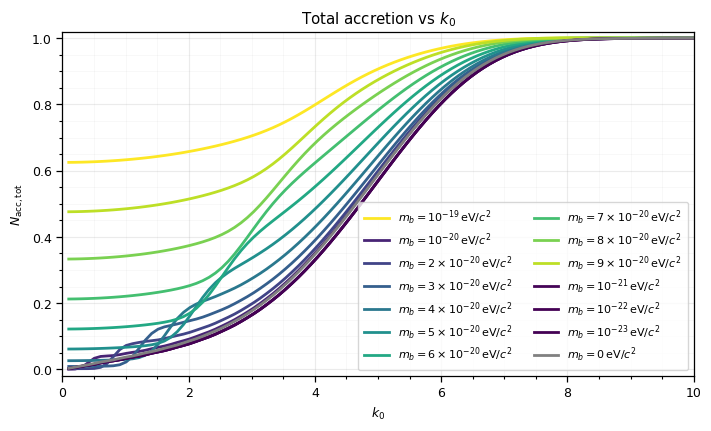

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import MaxNLocator

# --- estilo tipo paper ---
plt.rcParams.update({
    "font.size": 9,
    "axes.linewidth": 0.9,
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2.5,
    "ytick.minor.size": 2.5,
    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,
    "legend.frameon": True,
})

def Nacc_total_vs_k0(base_name,
                     base_dir="/home/flavio/Codes/KG-Y/sweep_k/",
                     N=100, KMIN=0.0, KMAX=10.0,
                     sort_k=True,
                     enforce_kmax=True):
    """
    Retorna (k_out, Nacc_tot_out) con k_out <= KMAX si enforce_kmax=True.
    """
    base_dir = os.path.abspath(base_dir)
    k_values = np.linspace(KMIN, KMAX, N, endpoint=True)

    kept_k = []
    kept_Nacc_tot = []

    for i in range(N):
        run_dir = os.path.join(base_dir, f"{base_name}{i:03d}")
        file_path = os.path.join(run_dir, "ncharge.h5")
        if not os.path.exists(file_path):
            continue

        ells, Nmode, F = load_modes_NF(file_path)

        N0 = np.array(Nmode[:, 0], dtype=float)
        Nf = np.array(Nmode[:, -1], dtype=float)

        N0_tot = np.sum(N0)
        Nf_tot = np.sum(Nf)

        if not np.isfinite(N0_tot) or abs(N0_tot) < 1e-300:
            continue

        Nacc_tot = 1.0 - (Nf_tot / N0_tot)
        if np.isfinite(Nacc_tot):
            kept_k.append(k_values[i])
            kept_Nacc_tot.append(Nacc_tot)

    k_out = np.array(kept_k, dtype=float)
    Nacc_tot_out = np.array(kept_Nacc_tot, dtype=float)

    if sort_k and len(k_out) > 1:
        order = np.argsort(k_out)
        k_out = k_out[order]
        Nacc_tot_out = Nacc_tot_out[order]

    # recorte explícito por seguridad
    if enforce_kmax and k_out.size > 0:
        m = (k_out >= KMIN) & (k_out <= KMAX)
        k_out = k_out[m]
        Nacc_tot_out = Nacc_tot_out[m]

    return k_out, Nacc_tot_out


def plot_total_accretion_series(
    series,
    base_dir="/home/flavio/Codes/KG-Y/sweep_k/",
    N=100, KMIN=0.0, KMAX=10.0,
    title=r"Total accretion vs $k_0$",
    savepath_pdf=None,
    savepath_png=None,
    show_markers=False,
    use_mass_gradient=True
):
    fig, ax = plt.subplots(figsize=(7.0, 4.2), constrained_layout=True)

    # --- Extraer masas y normalizar para el colormap ---
    if use_mass_gradient and all("mb" in s for s in series):
        masses = np.array([s["mb"] for s in series])
        # Filtrar masa = 0 para el cálculo (caso masless, lo ponemos al final)
        masses_nonzero = masses[masses > 0]
        mb_min = masses_nonzero.min()
        mb_max = masses_nonzero.max()
        norm = mcolors.Normalize(vmin=mb_min, vmax=mb_max)  # Normalización lineal
        cmap = plt.get_cmap("viridis")  # rojo (masa grande) -> azul (masa pequeña)
    else:
        use_mass_gradient = False

    # plot
    for idx, s in enumerate(series):
        k, Nacc = Nacc_total_vs_k0(
            s["base_name"],
            base_dir=base_dir,
            N=N, KMIN=KMIN, KMAX=KMAX,
            sort_k=True,
            enforce_kmax=True
        )

        # --- verificación de cobertura hasta k0=10 ---
        if k.size == 0:
            print(f"[WARN] {s['base_name']}: no hay puntos (no se encontraron ncharge.h5)")
            continue

        kmax_found = float(np.max(k))
        if kmax_found < (KMAX - 1e-12):
            print(f"[WARN] {s['base_name']}: k_max encontrado = {kmax_found:.4f} < {KMAX:.4f} "
                  f"(faltan runs/carpeta/archivo para llegar a k0={KMAX})")

        # --- Asignar color basado en masa ---
        if use_mass_gradient:
            mb = s["mb"]
            if mb > 0:
                color = cmap(norm(mb))
            else:
                # caso masless (m=0): gris oscuro al final
                color = "gray"
        else:
            color = None

        # estilo: línea limpia; marcadores opcionales (menos ruido)
        if show_markers:
            ax.plot(k, Nacc, marker="o", linewidth=1.8, markersize=2.0, label=s["label"], color=color)
        else:
            ax.plot(k, Nacc, linewidth=2.0, label=s["label"], color=color)

    # ejes
    ax.set_xlim(KMIN, KMAX)  # <-- esto fuerza visualmente hasta 10
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel(r"$k_0$")
    ax.set_ylabel(r"$N_{\mathrm{acc,tot}}$")
    ax.set_title(title, pad=6)

    ax.grid(True, which="major", alpha=0.25, linewidth=0.8)
    ax.minorticks_on()
    ax.grid(True, which="minor", alpha=0.10, linewidth=0.6)

    # ticks limpios
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

    # leyenda compacta (2 columnas) dentro
    ax.legend(loc="lower right", ncol=2, fontsize=8,
              borderpad=0.6, handlelength=2.2, labelspacing=0.4)

    # guardar
    if savepath_pdf:
        fig.savefig(savepath_pdf, format="eps", bbox_inches="tight")
    if savepath_png:
        fig.savefig(savepath_png, dpi=450, bbox_inches="tight")

    plt.show()
(17)

# ------------------ USO ------------------
series = [
    {"base_name":"k_m19_",  "label":r"$m_b=10^{-19}\,\mathrm{eV}/c^2$", "mb": 1e-19},
    {"base_name":"k_m20_",  "label":r"$m_b=10^{-20}\,\mathrm{eV}/c^2$", "mb": 1e-20},
    {"base_name":"k_2m20_", "label":r"$m_b=2\times10^{-20}\,\mathrm{eV}/c^2$", "mb": 2e-20},
    {"base_name":"k_3m20_", "label":r"$m_b=3\times10^{-20}\,\mathrm{eV}/c^2$", "mb": 3e-20},
    {"base_name":"k_4m20_", "label":r"$m_b=4\times10^{-20}\,\mathrm{eV}/c^2$", "mb": 4e-20},
    {"base_name":"k_5m20_", "label":r"$m_b=5\times10^{-20}\,\mathrm{eV}/c^2$", "mb": 5e-20},
    {"base_name":"k_6m20_", "label":r"$m_b=6\times10^{-20}\,\mathrm{eV}/c^2$", "mb": 6e-20},
    {"base_name":"k_7m20_", "label":r"$m_b=7\times10^{-20}\,\mathrm{eV}/c^2$", "mb": 7e-20},
    {"base_name":"k_8m20_", "label":r"$m_b=8\times10^{-20}\,\mathrm{eV}/c^2$", "mb": 8e-20},
    {"base_name":"k_9m20_", "label":r"$m_b=9\times10^{-20}\,\mathrm{eV}/c^2$", "mb": 9e-20},
    {"base_name":"k_m21_",  "label":r"$m_b=10^{-21}\,\mathrm{eV}/c^2$", "mb": 1e-21},
    {"base_name":"k_m22_",  "label":r"$m_b=10^{-22}\,\mathrm{eV}/c^2$", "mb": 1e-22},
    {"base_name":"k_m23_",  "label":r"$m_b=10^{-23}\,\mathrm{eV}/c^2$", "mb": 1e-23},
    {"base_name":"k_0m_",  "label":r"$m_b= 0\,\mathrm{eV}/c^2$", "mb": 0.0},
]

plot_total_accretion_series(
    series,
    base_dir="/home/flavio/Codes/KG-Y/sweep_k/",
    N=100, KMIN=0.0, KMAX=10.0,
    title=r"Total accretion vs $k_0$",
    savepath_pdf="Nacc_total_vs_k0.eps",
    savepath_png="Nacc_total_vs_k0.png",
    show_markers=False,
    use_mass_gradient=True
)

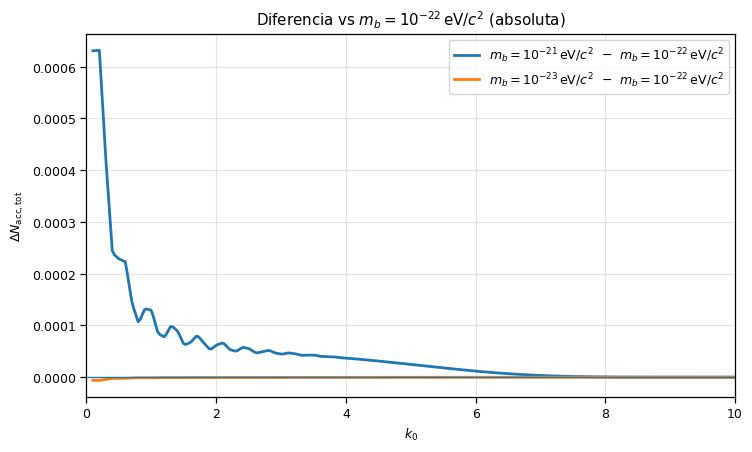

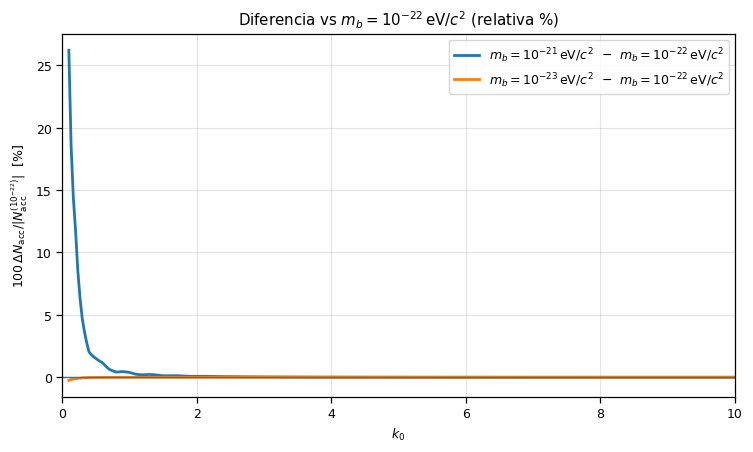

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def align_to_common_k(ref_k, ref_y, k, y, n_common=600):
    # rango común (intersección)
    kmin = max(np.min(ref_k), np.min(k))
    kmax = min(np.max(ref_k), np.max(k))
    if kmax <= kmin:
        raise RuntimeError("No hay traslape en k0 con la referencia.")
    k0 = np.linspace(kmin, kmax, n_common)
    y_ref = np.interp(k0, ref_k, ref_y)
    y_cur = np.interp(k0, k, y)
    return k0, y_cur, y_ref


def plot_vs_reference_mass(
    series,
    ref_label,
    base_dir,
    N=200, KMIN=0.0, KMAX=20.0,
    xlim=(0, 10),
    relative=False,
    title=None,
    savepath=None
):
    """
    series: lista de dicts [{"base_name":..., "label":...}, ...]
    ref_label: label EXACTO de la referencia (m=1e-22)
    """

    # 1) calcula todas las curvas
    curves = {}
    for s in series:
        k, y = Nacc_total_vs_k0(
            s["base_name"],
            base_dir=base_dir,
            N=N, KMIN=KMIN, KMAX=KMAX,
            sort_k=True
        )
        curves[s["label"]] = (k, y)

    if ref_label not in curves:
        raise ValueError(f"No encontré la referencia ref_label='{ref_label}' en series.")

    k_ref, y_ref = curves[ref_label]

    # 2) grafica diferencias vs referencia
    plt.figure(figsize=(7.6, 4.6))

    for lbl, (k, y) in curves.items():
        if lbl == ref_label:
            continue

        k0, y_cur_i, y_ref_i = align_to_common_k(k_ref, y_ref, k, y, n_common=600)
        diff = y_cur_i - y_ref_i

        if relative:
            denom = np.where(np.abs(y_ref_i) > 1e-12, np.abs(y_ref_i), np.nan)
            diff = 100.0 * diff / denom
            ylabel = r"$100\,\Delta N_{\mathrm{acc}}/|N_{\mathrm{acc}}^{(10^{-22})}|$  [%]"
        else:
            ylabel = r"$\Delta N_{\mathrm{acc,tot}}$"

        plt.plot(k0, diff, linewidth=2.0, label=fr"{lbl}  −  {ref_label}")

    plt.axhline(0.0, linewidth=1.0)
    plt.xlim(*xlim)
    plt.xlabel(r"$k_0$")
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.35)

    if title is None:
        title = (r"Diferencia vs $m_b=10^{-22}\,\mathrm{eV}/c^2$"
                 + (" (relativa %)" if relative else " (absoluta)"))
    plt.title(title)

    plt.legend(frameon=True)
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=300)
    plt.show()


# ------------------ USO ------------------
series = [
    {"base_name":"k_m21_", "label":r"$m_b=10^{-21}\,\mathrm{eV}/c^2$"},
    {"base_name":"k_m22_", "label":r"$m_b=10^{-22}\,\mathrm{eV}/c^2$"},  # referencia
    {"base_name":"k_m23_", "label":r"$m_b=10^{-23}\,\mathrm{eV}/c^2$"},
]

base_dir = "/home/flavio/Codes/KG-Y/sweep_k/"

# Diferencia absoluta vs 1e-22
plot_vs_reference_mass(
    series,
    ref_label=r"$m_b=10^{-22}\,\mathrm{eV}/c^2$",
    base_dir=base_dir,
    N=200, KMIN=0.0, KMAX=20.0,
    xlim=(0, 10),
    relative=False,
    savepath="DeltaNacc_vs_m22_abs.png"
)

# Diferencia relativa (%) vs 1e-22
plot_vs_reference_mass(
    series,
    ref_label=r"$m_b=10^{-22}\,\mathrm{eV}/c^2$",
    base_dir=base_dir,
    N=200, KMIN=0.0, KMAX=20.0,
    xlim=(0, 10),
    relative=True,
    savepath="DeltaNacc_vs_m22_rel.png"
)


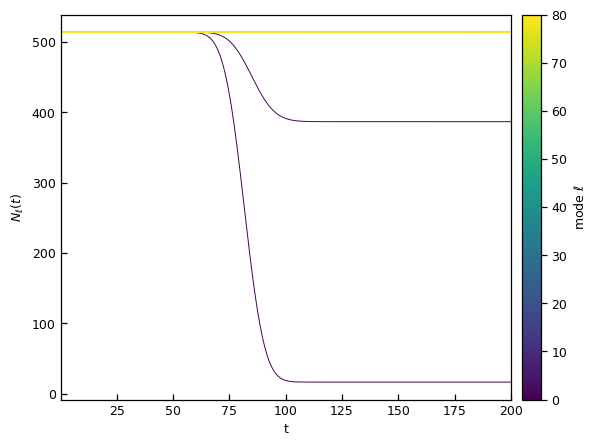

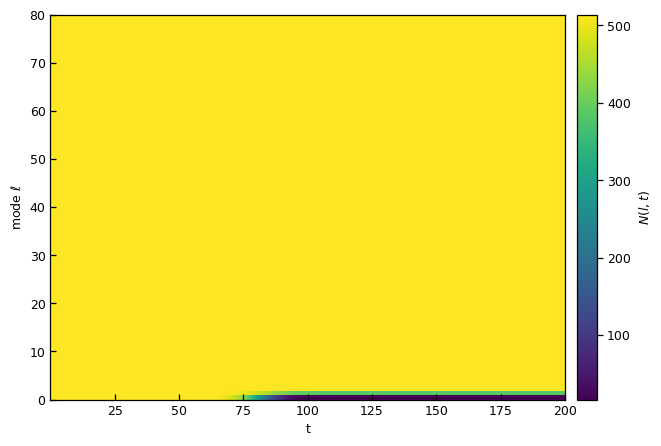

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import os
import re

filename = "k_05/ncharge.h5"


with h5.File(filename, 'r') as f:
    t = f["mode_00000_t"][:]


ells, N, F = load_modes_NF(filename, prefix="mode_")


order = np.argsort(ells)
ells_s = np.asarray(ells)[order]
N_s    = np.asarray(N)[order, :]


# =========================
# Gráfica de líneas con gradiente por ℓ
# =========================
fig, ax = plt.subplots(figsize=(7, 5))

norm = mpl.colors.Normalize(vmin=ells_s.min(), vmax=ells_s.max())
cmap = plt.get_cmap("viridis")  # puedes cambiar a "plasma", "magma", etc.

for ell, series in zip(ells_s, N_s):
    ax.plot(t, series, linewidth=0.7, color=cmap(norm(ell)))

ax.set_xlabel("t")
ax.set_ylabel(r"$N_\ell(t)$")

# Barra de color que mapea color -> ell
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r"mode $\ell$")

# Mejoras típicas de ejes (opcional)
ax.margins(x=0)
ax.tick_params(axis="both", which="both", direction="in")
plt.show()

# =========================
# Heatmap ℓ–t con ejes físicos (t y ℓ)
# =========================
fig, ax = plt.subplots(figsize=(8, 5))

# extent = [xmin, xmax, ymin, ymax] mapea la matriz a coordenadas reales
extent = [t.min(), t.max(), ells_s.min(), ells_s.max()]

im = ax.imshow(
    N_s,
    aspect="auto",
    origin="lower",
    extent=extent,
    interpolation="nearest",  # evita suavizado engañoso; cambia si quieres
)

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label(r"$N(l,t)$")

ax.set_xlabel("t")
ax.set_ylabel(r"mode $\ell$")
ax.tick_params(axis="both", which="both", direction="in")
plt.show()




Common t: (35996,) range: (np.float64(0.016667592644035778), np.float64(200.0)) dt~ 0.005555864214678595


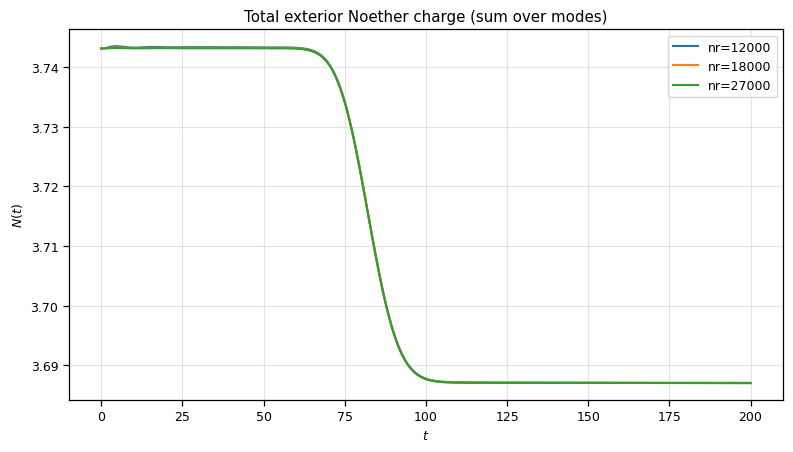

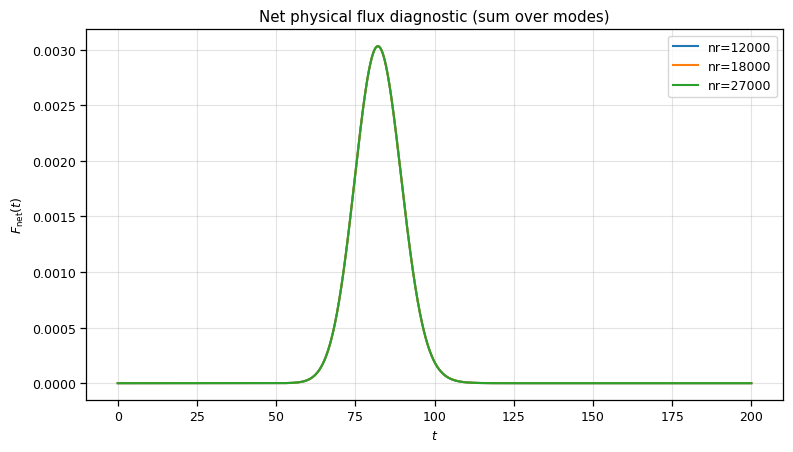

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
/tmp/ipykernel_7864/3258723696.py:50: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.sqrt(np.trapz(y*y, t) / (t[-1]-t[0]))



Δr (h): [0.04993749 0.03329074 0.02219341]
||D||_inf: [3.86163988e-04 1.71931119e-04 7.65019483e-05]
||D||_L2 : [1.45537073e-04 6.83511923e-05 3.16840012e-05]

Observed order p (sup norm): 12000→18000 = 1.9955176037266564  | 18000→27000 = 1.99706636599411
Observed order p (L2 time):   12000→18000 = 1.8638350214844877  | 18000→27000 = 1.8961237740074957

Global fit p (3 points): p_inf_fit = 1.9962919730704431  | p_L2_fit = 1.8799791519480484


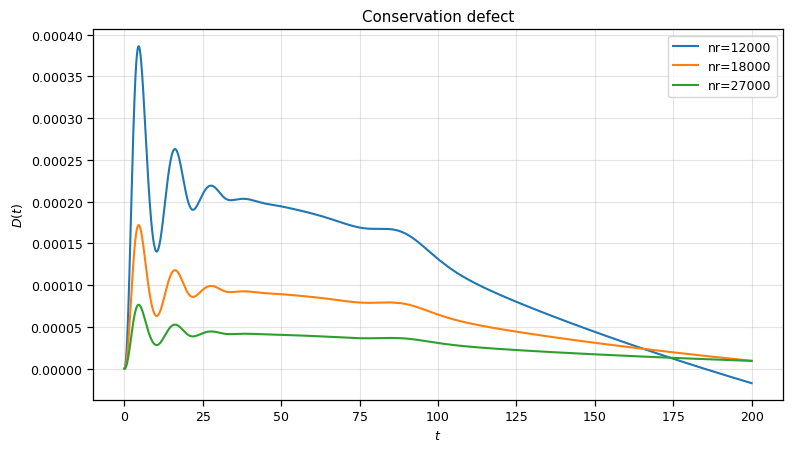

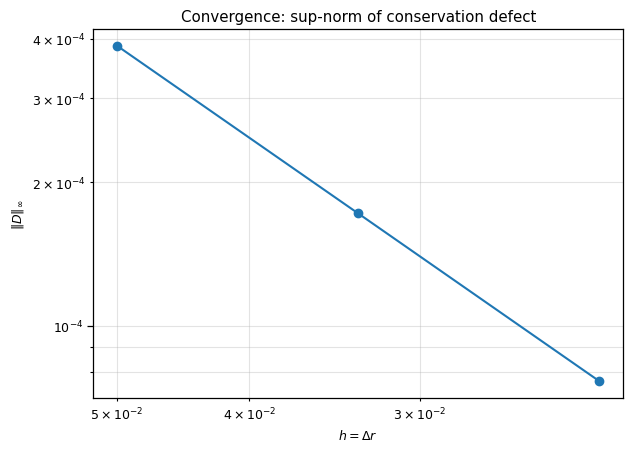

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


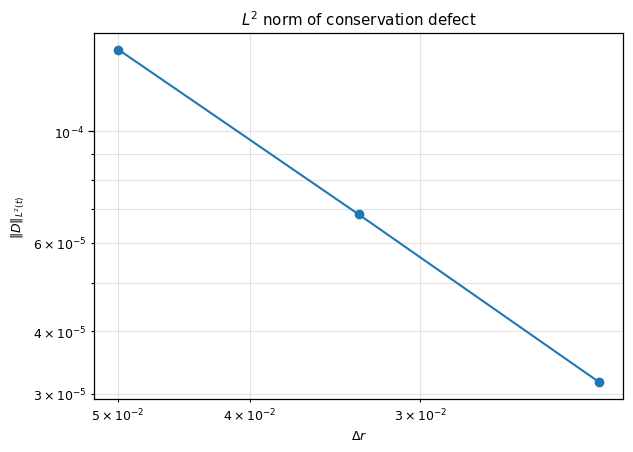

In [13]:
import numpy as np
import h5py as h5
import matplotlib.pyplot as plt
import re

# -------------------------
# Archivos (solo 3 resoluciones)
# -------------------------
files = [
    ("k_05_nr_12000/ncharge.h5", "nr=12000", 12000),
    ("k_05_nr_18000/ncharge.h5", "nr=18000", 18000),
    ("k_05_nr_27000/ncharge.h5", "nr=27000", 27000),
]

# Dominio radial (ajusta si tu simulación usa otros)
rmin = 0.8
rmax = 600.0

# -------------------------
# Loader por modo: N y F
# -------------------------
def load_modes_NF(filename, prefix="mode_"):
    pat = re.compile(rf"^{re.escape(prefix)}(\d{{5}})_(N|F)$")
    ells = []
    N_list, F_list = [], []
    with h5.File(filename, "r") as f:
        for k in f.keys():
            m = pat.match(k)
            if m and m.group(2) == "N":
                ells.append(int(m.group(1)))
        ells = np.array(sorted(set(ells)), dtype=int)
        for ell in ells:
            N_list.append(f[f"{prefix}{ell:05d}_N"][:])
            F_list.append(f[f"{prefix}{ell:05d}_F"][:])
    return ells, np.vstack(N_list), np.vstack(F_list)

def interp_modes(time_src, Usrc, t_tgt):
    return np.vstack([np.interp(t_tgt, time_src, Usrc[m]) for m in range(Usrc.shape[0])])

def cumtrapz_1d(y, x):
    I = np.zeros_like(y)
    dx = np.diff(x)
    I[1:] = np.cumsum(0.5*(y[1:]+y[:-1]) * dx)
    return I

def norm_inf(y):
    return np.max(np.abs(y))

def norm_L2_time(y, t):
    return np.sqrt(np.trapz(y*y, t) / (t[-1]-t[0]))

# -------------------------
# 1) Cargar tiempos, N, F
# -------------------------
times, Ns, Fs, labels, Nrs = [], [], [], [], []
for fn, lab, Nr in files:
    with h5.File(fn, "r") as f:
        times.append(f["mode_00000_t"][:])
    ells, N, F = load_modes_NF(fn)
    Ns.append(N); Fs.append(F)
    labels.append(lab); Nrs.append(Nr)

Nrs = np.array(Nrs, dtype=float)
hs  = (rmax - rmin) / (Nrs - 1.0)   # Δr para cada resolución

# -------------------------
# 2) Malla temporal común: usar la más fina (menor dt) y recortar solapamiento
# -------------------------
dts  = [tt[1]-tt[0] for tt in times]
iref = int(np.argmin(dts))
tref = times[iref]

tmin = max(tt[0]  for tt in times)
tmax = min(tt[-1] for tt in times)

mask = (tref >= tmin) & (tref <= tmax)
t = tref[mask]

print("Common t:", t.shape, "range:", (t[0], t[-1]), "dt~", (t[1]-t[0]))

# -------------------------
# 3) Interpolar N y F a t, sumar sobre modos, construir defecto D
# -------------------------
Ntot_list, Ftot_list, D_list = [], [], []

for time_i, N_i, F_i in zip(times, Ns, Fs):
    Nc = interp_modes(time_i, N_i, t)
    Fc = interp_modes(time_i, F_i, t)

    Ntot = Nc.sum(axis=0)
    Ftot = Fc.sum(axis=0)

    I = cumtrapz_1d(Ftot, t)
    D = (Ntot - Ntot[0]) + I


    Ntot_list.append(Ntot)
    Ftot_list.append(Ftot)
    D_list.append(D)

# -------------------------
# 4) Gráficas: N(t), F(t), D(t)
# -------------------------
plt.figure(figsize=(8,4.6))
for Ntot, lab in zip(Ntot_list, labels):
    plt.plot(t, Ntot, label=lab)
plt.xlabel(r"$t$")
plt.ylabel(r"$N(t)$")
plt.title("Total exterior Noether charge (sum over modes)")
plt.grid(True, alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4.6))
for Ftot, lab in zip(Ftot_list, labels):
    plt.plot(t, Ftot, label=lab)
plt.xlabel(r"$t$")
plt.ylabel(r"$F_{\rm net}(t)$")
plt.title("Net physical flux diagnostic (sum over modes)")
plt.grid(True, alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4.6))
for D, lab in zip(D_list, labels):
    plt.plot(t, D, label=lab)
plt.xlabel(r"$t$")
plt.ylabel(r"$D(t)$")
plt.title(r"Conservation defect")
plt.grid(True, alpha=0.35)
plt.legend()
plt.tight_layout()
plt.savefig("noether_defect_time.eps", format="eps")

# -------------------------
# 5) Métricas de error y orden observado
# -------------------------
Einf = np.array([norm_inf(D) for D in D_list])
EL2  = np.array([norm_L2_time(D, t) for D in D_list])

print("\nΔr (h):", hs)
print("||D||_inf:", Einf)
print("||D||_L2 :", EL2)

# Orden por pares (no asume factor fijo)
def p_pair(err_a, err_b, h_a, h_b, eps=1e-300):
    return np.log((err_a+eps)/(err_b+eps)) / np.log(h_a/h_b)

p_inf_12_18 = p_pair(Einf[0], Einf[1], hs[0], hs[1])
p_inf_18_27 = p_pair(Einf[1], Einf[2], hs[1], hs[2])

p_L2_12_18  = p_pair(EL2[0],  EL2[1],  hs[0], hs[1])
p_L2_18_27  = p_pair(EL2[1],  EL2[2],  hs[1], hs[2])

print("\nObserved order p (sup norm): 12000→18000 =", p_inf_12_18, " | 18000→27000 =", p_inf_18_27)
print("Observed order p (L2 time):   12000→18000 =", p_L2_12_18,  " | 18000→27000 =", p_L2_18_27)

# Ajuste global con 3 puntos: log(E)=p log(h)+c
def fit_p(h, E):
    x = np.log(h)
    y = np.log(E)
    p, c = np.polyfit(x, y, 1)
    return p, c

p_inf_fit, _ = fit_p(hs, Einf)
p_L2_fit,  _ = fit_p(hs, EL2)

print("\nGlobal fit p (3 points): p_inf_fit =", p_inf_fit, " | p_L2_fit =", p_L2_fit)

# -------------------------
# 6) Log-log: error vs h
# -------------------------
plt.figure(figsize=(6.4,4.6))
plt.loglog(hs, Einf, marker="o")
plt.gca().invert_xaxis()
plt.xlabel(r"$h=\Delta r$")
plt.ylabel(r"$\|D\|_\infty$")
plt.title("Convergence: sup-norm of conservation defect")
plt.grid(True, which="both", alpha=0.35)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6.4,4.6))
plt.loglog(hs, EL2, marker="o")
plt.gca().invert_xaxis()
plt.xlabel(r"$\Delta r$")
plt.ylabel(r"$\|D\|_{L^2(t)}$")
plt.title(R"$L^2$ norm of conservation defect")
plt.grid(True, which="both", alpha=0.35)
plt.tight_layout()
plt.savefig("noether_defect_L2.eps", format="eps")



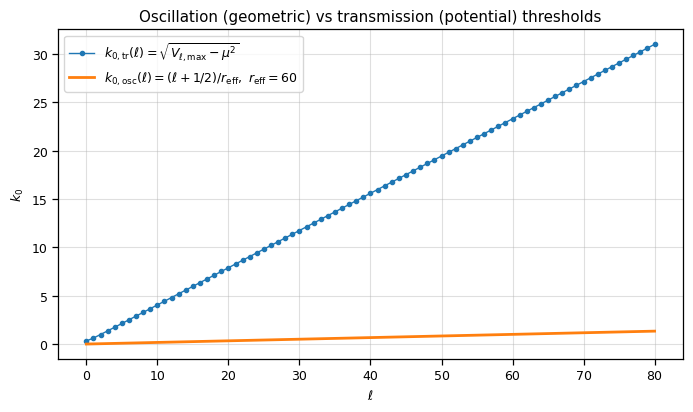

ell   r_max        V_max           k0_tr        k0_osc
  0    1.333334   1.05469e-01    0.324760    0.008333
  1    1.443001   3.97046e-01    0.630116    0.025000
  2    1.475857   9.88467e-01    0.994217    0.041667
  5    1.494605   4.54339e+00    2.131523    0.091667
 10    1.498497   1.63951e+01    4.049088    0.175000
 20    1.499604   6.23210e+01    7.894365    0.341667
 40    1.499899   2.43062e+02   15.590437    0.675000
 80    1.499974   9.60099e+02   30.985461    1.341667


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parameters (edit as needed)
# -----------------------------
R_s = 1.0
mu  = 0.0  # scalar mass (dimensionless). Set to your value.

# Packet parameters for the oscillation line
sigma = 10.0
r0    = 80.0

# Choose r_eff for oscillation threshold:
#   "center" -> r_eff = r0
#   "inner"  -> r_eff = r0 - 2*sigma  (conservative)
osc_choice = "inner"

# Ell range
ell_max = 80
ells = np.arange(0, ell_max + 1)

# Search domain for V_eff maximum
rmax_search = 1e4  # in units of R_s
n_coarse    = 25000

# -----------------------------
# Effective potential
# -----------------------------
def V_eff(r, ell):
    L = ell * (ell + 1.0)
    return (1.0 - R_s / r) * (mu**2 + L / r**2 + R_s / r**3)

def k0_tr_numeric(ell, rmax_search=rmax_search, n_coarse=n_coarse):
    """
    Estimate r_max and V_max for V_eff(r, ell), then compute
    k0_tr(ell) = sqrt(max(V_max - mu^2, 0)).
    Uses:
      1) coarse logspace scan
      2) local parabolic refinement around the discrete maximum
    """
    eps = 1e-10
    r = np.logspace(np.log10(R_s * (1.0 + eps)), np.log10(rmax_search * R_s), n_coarse)
    V = V_eff(r, ell)

    i = int(np.argmax(V))

    # Parabolic refinement around i (if interior)
    if 0 < i < len(r) - 1:
        x1, x2, x3 = r[i-1], r[i], r[i+1]
        y1, y2, y3 = V[i-1], V[i], V[i+1]

        denom = (x1 - x2) * (x1 - x3) * (x2 - x3)
        a = (x3 * (y2 - y1) + x2 * (y1 - y3) + x1 * (y3 - y2)) / denom
        b = (x3**2 * (y1 - y2) + x2**2 * (y3 - y1) + x1**2 * (y2 - y3)) / denom

        if a < 0.0:
            r_peak = -b / (2.0 * a)
            # clamp to local bracket to avoid silly extrapolation
            r_peak = min(max(r_peak, min(x1, x3)), max(x1, x3))
            V_peak = V_eff(r_peak, ell)
        else:
            r_peak, V_peak = x2, y2
    else:
        r_peak, V_peak = r[i], V[i]

    k_tr = np.sqrt(max(V_peak - mu**2, 0.0))
    return r_peak, V_peak, k_tr

# -----------------------------
# Build k0_tr(ell)
# -----------------------------
r_max_arr = np.zeros_like(ells, dtype=float)
V_max_arr = np.zeros_like(ells, dtype=float)
k_tr_arr  = np.zeros_like(ells, dtype=float)

for j, ell in enumerate(ells):
    rmax, Vmax, ktr = k0_tr_numeric(int(ell))
    r_max_arr[j] = rmax
    V_max_arr[j] = Vmax
    k_tr_arr[j]  = ktr

# -----------------------------
# Build k0_osc(ell)
# -----------------------------
if osc_choice.lower() == "inner":
    r_eff = r0 - 2.0 * sigma
elif osc_choice.lower() == "center":
    r_eff = r0
else:
    raise ValueError("osc_choice must be 'inner' or 'center'")

k_osc_arr = (ells + 0.5) / r_eff

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(7.0, 4.2))
plt.plot(ells, k_tr_arr, marker="o", ms=3, lw=1,
         label=r"$k_{0,\mathrm{tr}}(\ell)=\sqrt{V_{\ell,\max}-\mu^2}$")
plt.plot(ells, k_osc_arr, lw=2,
         label=rf"$k_{{0,\mathrm{{osc}}}}(\ell)=(\ell+1/2)/r_\mathrm{{eff}},\ r_\mathrm{{eff}}={r_eff:g}$")

plt.xlabel(r"$\ell$")
plt.ylabel(r"$k_0$")
plt.title(r"Oscillation (geometric) vs transmission (potential) thresholds")
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

# Small sanity table
print("ell   r_max        V_max           k0_tr        k0_osc")
for ell in [0, 1, 2, 5, 10, 20, 40, 80]:
    idx = int(ell)
    print(f"{ell:3d}  {r_max_arr[idx]:10.6f}  {V_max_arr[idx]:12.5e}  {k_tr_arr[idx]:10.6f}  {k_osc_arr[idx]:10.6f}")


In [1]:
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import re

def n_to_ellm(n):
    ell = int(np.sqrt(n))
    r = n - ell * ell
    m = int(r) - ell
    return ell, m

def read_modes_h5(h5_path, tmax=1800.0):
    mode_ids = []
    ells = []
    Ns = []
    Fs = []

    with h5.File(h5_path, "r") as f:
        mode_keys = sorted(
            [k for k in f.keys() if k.startswith("mode_")],
            key=lambda s: int(s.split("_")[1])
        )

        if not mode_keys:
            raise RuntimeError(f"No encontré grupos mode_xxxxx en {h5_path}")

        nt_ref = None

        for key in mode_keys:
            n = int(key.split("_")[1])
            ell, mm = n_to_ellm(n)

            g = f[key]
            if "N" not in g or "F" not in g:
                print(f"[WARN] {h5_path}:{key} no tiene N o F, se omite.")
                continue

            N = np.asarray(g["N"][:], dtype=np.float64)
            F = np.asarray(g["F"][:], dtype=np.float64)

            if N.ndim != 1 or F.ndim != 1:
                print(f"[WARN] {h5_path}:{key} tiene N o F con dimensión != 1, se omite.")
                continue

            if len(N) != len(F):
                print(f"[WARN] {h5_path}:{key} tiene longitudes distintas en N y F, se omite.")
                continue

            if nt_ref is None:
                nt_ref = len(N)
            elif len(N) != nt_ref:
                print(f"[WARN] {h5_path}:{key} tiene longitud distinta ({len(N)} vs {nt_ref}), se omite.")
                continue

            mode_ids.append(n)
            ells.append(ell)
            Ns.append(N)
            Fs.append(F)

    if len(Ns) == 0:
        raise RuntimeError(f"No encontré modos válidos en {h5_path}")

    Ns = np.asarray(Ns)
    Fs = np.asarray(Fs)
    t = np.linspace(0.0, tmax, Ns.shape[1])

    return mode_ids, ells, Ns, Fs, t

def plot_normalized_N(t, ells, Ns, k0, outpath):
    # Normalización robusta
    N0 = Ns[:, 0].copy()
    N0_safe = np.where(np.abs(N0) > 0.0, N0, np.nan)
    Ns_norm = Ns / N0_safe[:, None]

    fig, ax = plt.subplots(figsize=(7, 5))

    norm = mpl.colors.Normalize(vmin=np.min(ells), vmax=np.max(ells))
    cmap = plt.get_cmap("viridis")

    for ell, series in zip(ells, Ns_norm):
        ax.plot(t, series, linewidth=0.7, color=cmap(norm(ell)))

    ax.set_xlabel("t")
    ax.set_ylabel(r"$N_\ell(t)/N_\ell(0)$")
    ax.set_title(rf"Noether charge $k_0={k0}$")

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(r"mode $\ell$")

    fig.tight_layout()
    fig.show()
    #fig.savefig(outpath, dpi=200, bbox_inches="tight")
    #plt.close(fig)


# ============================================================
# Graficar F = dN/dt
# ============================================================
def plot_F(t, ells, Fs, k0, outpath):
    fig, ax = plt.subplots(figsize=(7, 5))

    norm = mpl.colors.Normalize(vmin=np.min(ells), vmax=np.max(ells))
    cmap = plt.get_cmap("viridis")

    for ell, series in zip(ells, Fs):
        ax.plot(t, series, linewidth=0.7, color=cmap(norm(ell)))

    ax.set_xlabel("t")
    ax.set_ylabel(r"$\dot N_\ell(t)$")
    ax.set_title(rf"$\dot{{N}}_\ell(t)$  ($k_0={k0}$)")

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(r"mode $\ell$")

    fig.tight_layout()
    fig.show()
    #fig.savefig(outpath, dpi=200, bbox_inches="tight")
    #plt.close(fig)


filename = "/home/flavio/Codes/KG-Y/k_m20_001/modes.h5"

mode_ids, ells, Ns, Fs, t = read_modes_h5(filename)

k0 = 0.1

plot_F(t, ells, Fs, k0, "F_plot.png")
plot_normalized_N(t, ells, Ns, k0, "N_plot.png")


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/home/flavio/Codes/KG-Y/k_m20_001/modes.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)